# 215. Kth Largest Element in an Array
https://leetcode.com/problems/kth-largest-element-in-an-array/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Min-heap of size k | $O(n \log k)$ | $O(k)$ | Optimal for streaming |
| Quickselect | $O(n)$ avg, $O(n^2)$ worst | $O(1)$ | In-place, average-case optimal |
| Sort | $O(n \log n)$ | $O(1)$-$O(n)$ | Simple but slower |

## Methodology

Use a min-heap of size k. Iterate through the array; push each element, and if the heap exceeds size k, pop the minimum. After processing all elements, the heap top is the kth largest. This gives O(n log k) time and O(k) space. Quickselect is also shown in some languages for O(n) average time.

## Solutions

### C#

In [ ]:
public class Solution {
    public int FindKthLargest(int[] nums, int k) {
        var pq = new PriorityQueue<int, int>();
        foreach (int num in nums) {
            pq.Enqueue(num, num);
            if (pq.Count > k)
                pq.Dequeue();
        }
        return pq.Peek();
    }
}

### Python

In [ ]:
import heapq

class Solution:
    def findKthLargest(self, nums: list[int], k: int) -> int:
        heap = []
        for num in nums:
            heapq.heappush(heap, num)
            if len(heap) > k:
                heapq.heappop(heap)
        return heap[0]

### Go

In [ ]:
import "container/heap"

type MinHeap []int
func (h MinHeap) Len() int           { return len(h) }
func (h MinHeap) Less(i, j int) bool { return h[i] < h[j] }
func (h MinHeap) Swap(i, j int)      { h[i], h[j] = h[j], h[i] }
func (h *MinHeap) Push(x any)        { *h = append(*h, x.(int)) }
func (h *MinHeap) Pop() any {
    old := *h
    n := len(old)
    x := old[n-1]
    *h = old[:n-1]
    return x
}

func findKthLargest(nums []int, k int) int {
    h := &MinHeap{}
    heap.Init(h)
    for _, num := range nums {
        heap.Push(h, num)
        if h.Len() > k {
            heap.Pop(h)
        }
    }
    return (*h)[0]
}

### Rust

In [ ]:
use std::collections::BinaryHeap;
use std::cmp::Reverse;

impl Solution {
    pub fn find_kth_largest(nums: Vec<i32>, k: i32) -> i32 {
        let k = k as usize;
        let mut heap = BinaryHeap::new();
        for num in nums {
            heap.push(Reverse(num));
            if heap.len() > k {
                heap.pop();
            }
        }
        heap.peek().unwrap().0
    }
}

## Example Scenarios

### 1. Common Case — Finding 2nd Largest
**Input:** `nums = [3, 2, 1, 5, 6, 4], k = 2`

Maintain a min-heap of size 2. Push each element; pop the minimum if heap size exceeds 2. After all elements, the heap contains {5, 6} and the top (minimum of the two largest) is 5.

WHY it's tricky: It isn't — validates that the min-heap correctly retains the k largest elements.

$n = 6,\ k = 2. \text{ Operations: } 6 \text{ pushes} + 4 \text{ pops} = O(n \log k) = O(6)$

### 2. Slightly Complex — Duplicates and k in the Middle
**Input:** `nums = [3, 2, 3, 1, 2, 4, 5, 5, 6], k = 4`

Duplicates (two 3's, two 2's, two 5's) fill multiple heap slots. Sorted descending: [6,5,5,4,3,3,2,2,1]. The 4th largest is 4, not 3. The min-heap of size 4 ends with {4,5,5,6}.

WHY it's tricky: Each duplicate counts as a separate element. The 4th largest is 4, not 3 — a common mistake when candidates confuse "4th distinct largest" with "4th largest."

$n = 9,\ k = 4. \text{ } O(n \log k) = O(9 \times \log 4) = O(18)$

### 3. Edge Case: Time Factor — n = 10^5, k = 1
**Input:** `nums = [random 100,000 elements], k = 1`

When k = 1, the min-heap has size 1. This degenerates to finding the maximum: O(n) with log(1) = 0 heapify cost per operation. Best case for the heap approach.

WHY it's tricky: As k grows toward n, $O(n \log k)$ approaches $O(n \log n)$, matching sort. Quickselect gives $O(n)$ average for any k but risks $O(n^2)$ worst case.

$O(n \log k) = O(10^5 \times \log 1) = O(10^5)$

### 4. Edge Case: Space Factor — k = n (All Elements in Heap)
**Input:** `nums = [5, 3, 8, 1, 9, 2, 7, 4, 6], k = 9`

When k = n, the min-heap holds all n elements. No pops occur. The top is the minimum (9th largest = smallest). Space is O(n), offering no advantage over sorting.

WHY it's tricky: Space is O(k). When k = n, heap holds entire array. For k close to n, consider finding the (n−k+1)th smallest with a max-heap of size (n−k+1) instead.

$\text{Space} = O(k) = O(n). \text{ Heap top} = \min = 1 \text{ (9th largest of 9 elements)}$

### 5. Almost-Impossible — 10^5 Elements at Value Boundaries
**Input:** `nums = [-10^4, -10^4, ..., 10^4, 10^4]` (50K of each), `k = 50001`

Half elements are -10,000, half are 10,000. The 50,001st largest skips all 50,000 copies of 10,000 — the answer is -10,000. The min-heap of size 50,001 holds all 10,000's plus one -10,000.

WHY it's tricky: The k value is just past the boundary between the two value groups, testing whether the heap correctly maintains exactly k elements and returns the boundary value.

$O(n \log k) = O(10^5 \times \log 50001) \approx O(1.56 \times 10^6)$


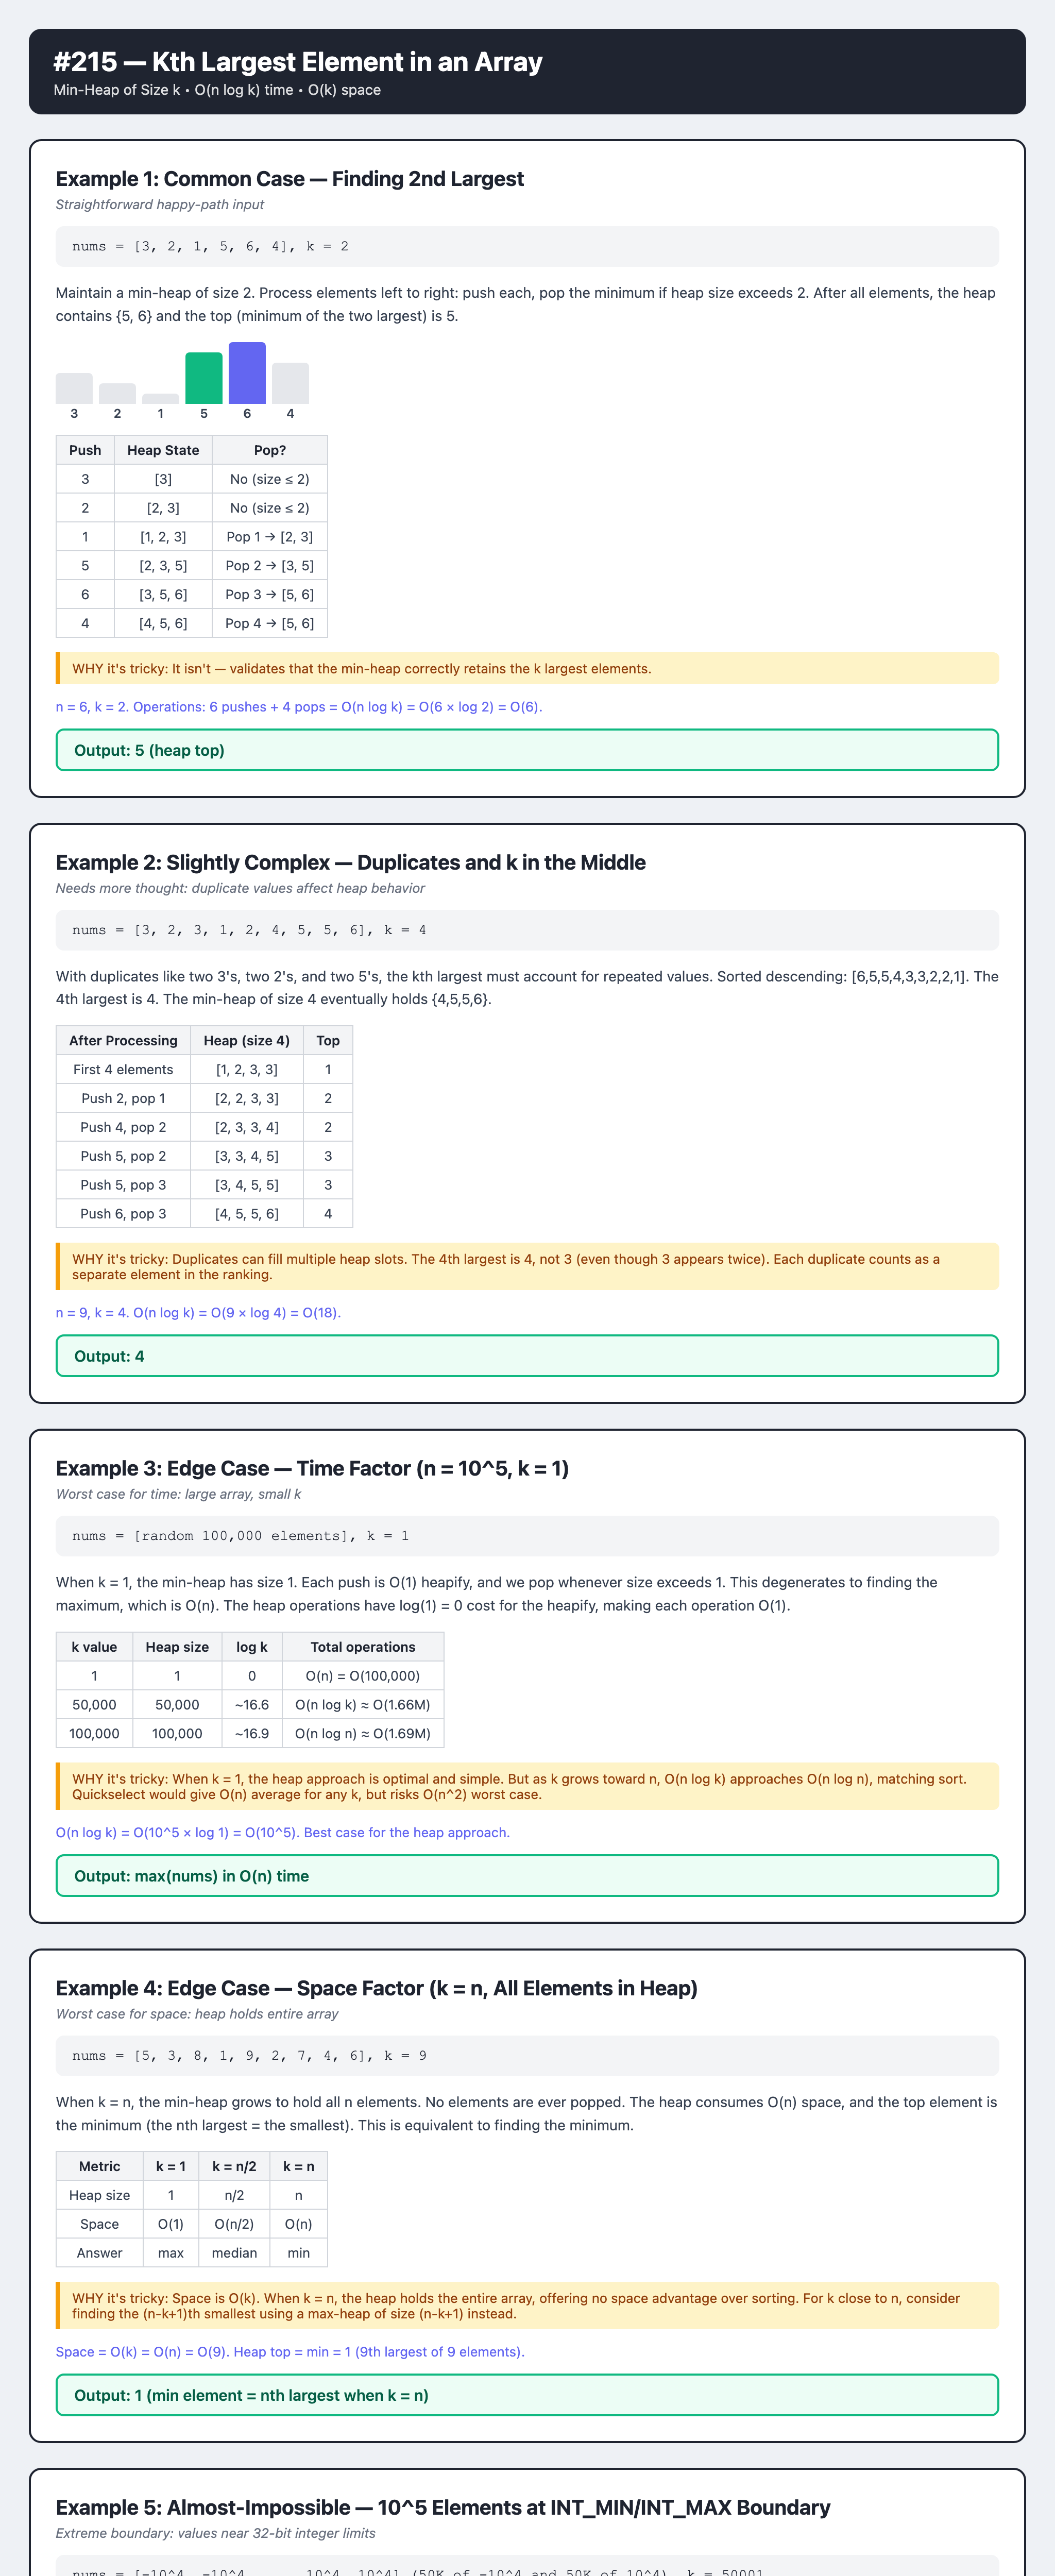